** PageIndex Introduction :
PageIndex is a new reasoning-based, vectorless RAG framework that performs retrieval in two steps:

1. Generate a tree structure index of documents
2. Perform reasoning-based retrieval through tree search

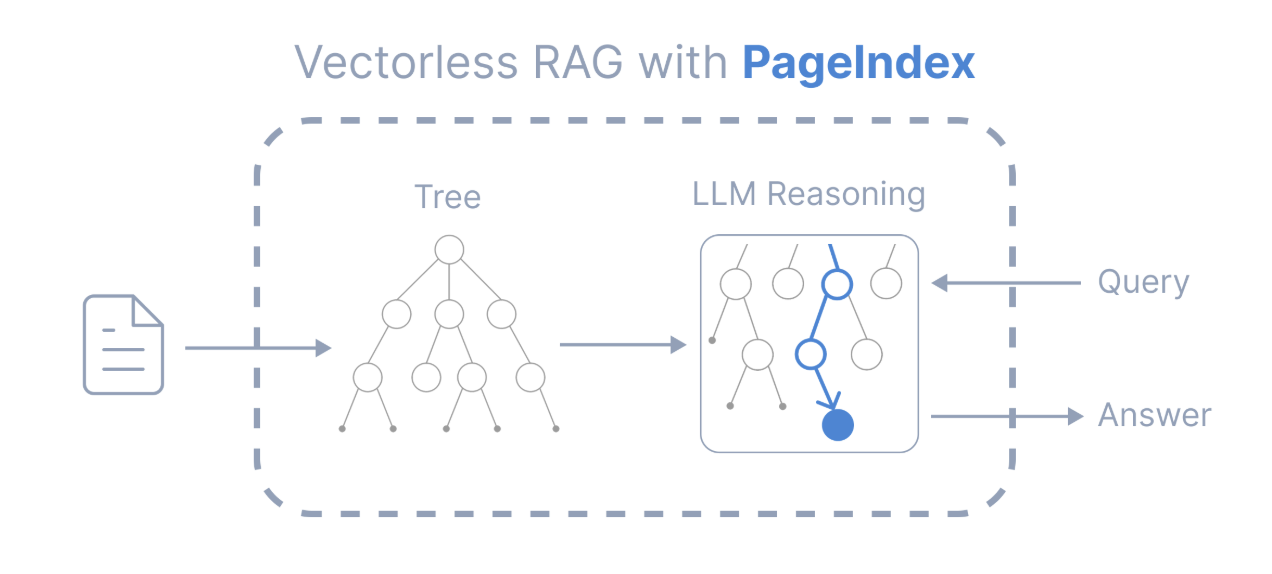

Compared to traditional vector-based RAG, PageIndex features:

- No Vectors Needed: Uses document structure and LLM reasoning for retrieval.
- No Chunking Needed: Documents are organized into natural sections rather than artificial chunks.
- Human-like Retrieval: Simulates how human experts navigate and extract knowledge from complex documents.
- Transparent Retrieval Process: Retrieval based on reasoning — say goodbye to approximate semantic search ("vibe retrieval").

Install PageIndex

In [1]:
%pip install -q --upgrade pageindex

Setup PageIndex

In [5]:
from pageindex import PageIndexClient
import pageindex.utils as utils

# Get your PageIndex API key from https://dash.pageindex.ai/api-keys
PAGEINDEX_API_KEY = "your PageIndex API key"
pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY)

Setup LLM

In [6]:
import openai
OPENAI_API_KEY = "your_openai-api-key"

async def call_llm(prompt, model="gpt-4o-mini", temperature=0):
    client = openai.AsyncOpenAI(api_key=OPENAI_API_KEY)
    response = await client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature
    )
    return response.choices[0].message.content.strip()

Submit a document for generating PageIndex tree

In [17]:
import os, requests

pdf_url = "https://www.utep.edu/business/_files/docs/degree-plans/finance.pdf"
pdf_path = os.path.join("../data", pdf_url.split('/')[-1])
os.makedirs(os.path.dirname(pdf_path), exist_ok=True)

response = requests.get(pdf_url)
with open(pdf_path, "wb") as f:
    f.write(response.content)
print(f"Downloaded {pdf_url}")

doc_id = pi_client.submit_document(pdf_path)["doc_id"]
print('Document Submitted:', doc_id)

Downloaded https://www.utep.edu/business/_files/docs/degree-plans/finance.pdf
Document Submitted: pi-cmnh6astu0afz01r4gkxa5tb3


Get the generated PageIndex tree structure

In [23]:
tree = pi_client.get_tree(doc_id, node_summary=True)['result']
print('Simplified Tree Structure of the Document:')
utils.print_tree(tree)

Simplified Tree Structure of the Document:
[{'title': 'Preface',
  'node_id': '0000',
  'summary': 'THE UNIVERSITY OF TEXAS AT EL PASO\n\nColl...'},
 {'title': 'What is Finance?',
  'node_id': '0001',
  'prefix_summary': '# What is Finance?\n\n- "Finance" is a bro...',
  'nodes': [{'title': 'Finance majors (usually...)',
             'node_id': '0002',
             'summary': '## Finance majors (usually...)\n\n- Financ...'},
            {'title': 'Financial Analyst VS General Finance',
             'node_id': '0003',
             'summary': '## Financial Analyst VS General Finance\n...'}]},
 {'title': 'Career Paths in Finance',
  'node_id': '0004',
  'summary': '# Career Paths in Finance\n\n- Investment ...'},
 {'title': 'Work Environment',
  'node_id': '0005',
  'prefix_summary': '# Work Environment\n\n- Financial analysts...',
  'nodes': [{'title': "Major Requirements at UTEP's COBA",
             'node_id': '0006',
             'summary': "## Major Requirements at UTEP's COBA\n\nIn.

Use LLM for tree search and identify nodes that might contain relevant context

In [24]:
import json

query = "What are the conclusions in this document?"

tree_without_text = utils.remove_fields(tree.copy(), fields=['text'])

search_prompt = f"""
You are given a question and a tree structure of a document.
Each node contains a node id, node title, and a corresponding summary.
Your task is to find all nodes that are likely to contain the answer to the question.

Question: {query}

Document tree structure:
{json.dumps(tree_without_text, indent=2)}

Please reply in the following JSON format:
{{
    "thinking": "<Your thinking process on which nodes are relevant to the question>",
    "node_list": ["node_id_1", "node_id_2", ..., "node_id_n"]
}}
Directly return the final JSON structure. Do not output anything else.
"""

tree_search_result = await call_llm(search_prompt)

Print retrieved nodes and reasoning process

In [25]:
node_map = utils.create_node_mapping(tree)
tree_search_result_json = json.loads(tree_search_result)

print('Reasoning Process:')
utils.print_wrapped(tree_search_result_json['thinking'])

print('\nRetrieved Nodes:')
for node_id in tree_search_result_json["node_list"]:
    node = node_map[node_id]
    print(f"Node ID: {node['node_id']}\t Page: {node['page_index']}\t Title: {node['title']}")

Reasoning Process:
To find the conclusions in the document, I need to look for sections that summarize findings or
provide final thoughts. The 'Job Outlook for Finance' section discusses projections and trends,
which could be considered a conclusion about the future of finance careers. Additionally, the
'Career Paths in Finance' section outlines various career options, which may also contain concluding
insights about the field. The 'Sample Job Titles' section could provide context for conclusions
about job roles in finance. Therefore, I will include these nodes as they are likely to contain
relevant conclusions.

Retrieved Nodes:
Node ID: 0004	 Page: 6	 Title: Career Paths in Finance
Node ID: 0008	 Page: 10	 Title: Job Outlook for Finance
Node ID: 0007	 Page: 9	 Title: Sample Job Titles


Extract relevant context from retrieved nodes

In [26]:
node_list = json.loads(tree_search_result)["node_list"]
relevant_content = "\n\n".join(node_map[node_id]["text"] for node_id in node_list)

print('Retrieved Context:\n')
utils.print_wrapped(relevant_content[:1000] + '...')

Retrieved Context:

# Career Paths in Finance

- Investment Banking
- Personal Finance
- Asset Management
- Sales and Trading
- Investment Research
- Financial Advisory
- Portfolio Management
- Corporate Finance
- Insurance


# Job Outlook for Finance

- Employment of financial analysts is projected to grow 16% from 2012 to 2022, faster than the
average for all occupations. A growing range of financial products and the need for in-depth
knowledge of geographic regions are expected to lead to strong employment growth.
- Employment of financial examiners is projected to grow 6% percent from 2012 to 2022, slower than
the average for all occupations. New regulations will likely create a need for more examiners,
though declining employment in federal government will slow growth for these workers.

www.bls.gov


# Sample Job Titles

- Personal Financial Planner
- Commercial Bank Management
- Savings and Loan Management
- Investment Banking
- Sales &amp; Trading
- Stock Brokerage
- Insurance


Generate answer based on retrieved context

In [27]:
answer_prompt = f"""
Answer the question based on the context:

Question: {query}
Context: {relevant_content}

Provide a clear, concise answer based only on the context provided.
"""

print('Generated Answer:\n')
answer = await call_llm(answer_prompt)
utils.print_wrapped(answer)


Generated Answer:

The conclusions in the document indicate that the finance sector offers a variety of career paths,
including investment banking, personal finance, and asset management, among others. The job outlook
for financial analysts is positive, with a projected growth of 16% from 2012 to 2022, driven by the
demand for diverse financial products and regional expertise. In contrast, the employment growth for
financial examiners is slower at 6%, influenced by new regulations but hindered by declining federal
government employment.
